# Mobility Insight Kit — Seattle shared micromobility demand analyzer

**Author:** Zhian Hu · **Course:** HCDE 530 · **Track:** Research

**What this tool does:** Helps **UX researchers, service designers, and mobility product teams** turn large-scale Seattle open data into **repeatable demand-pattern insights** — peak windows, weekday/weekend differences, directional imbalance, and seasonal trends — without writing one-off pandas scripts for every study.

**Data source:** [Fremont Bridge — Combined Bicycle and Scooter Counter](https://data.seattle.gov/Transportation/Shared-Mobility-Program-Data/65db-xm6k) (City of Seattle Open Data). Hourly counts on the Fremont Bridge corridor proxy **when** micromobility intensity peaks on a critical urban link.

> **MP2a note:** Trip-level vendor logs (start/end/provider) are not published as open CSV on Seattle’s portal. This tool uses the **public counter feed** at your declared program URL and documents that scope choice in `reflection.md`.

> **Viewing on GitHub:** Interactive Plotly output does not render in GitHub's notebook viewer. Charts below are saved as **PNG** and embedded so they appear in the browser without running Python.

In [1]:
# Setup — run first
!pip install -q jupyter pandas plotly kaleido nbformat

zsh:1: command not found: pip


In [2]:
from pathlib import Path
import sys

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import Image, display

MP2_DIR = Path.cwd().resolve()
if str(MP2_DIR) not in sys.path:
    sys.path.insert(0, str(MP2_DIR))

from mobility_insights import (
    build_insight_report,
    direction_balance,
    load_and_clean,
    low_activity_windows,
    monthly_trend,
    peak_hours,
    weekday_weekend_compare,
    COL_TOTAL,
)

DATA_PATH = MP2_DIR / "data" / "fremont_micromobility_hourly.csv"
FIG_DIR = MP2_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f"Missing {DATA_PATH} — run notebook from MP2/ folder."
print("Tool root:", MP2_DIR)

Tool root: /Users/hza25/Desktop/hcde530/MP2


---
## 1 · Load & clean

The helper module `mobility_insights.py` standardizes column names and derives research-friendly fields (`hour`, `weekday`, `is_weekend`, `west_share`).

In [3]:
df = load_and_clean(DATA_PATH)
print(df.shape)
df.head(3)

/Users/hza25/Desktop/hcde530/MP2/mobility_insights.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[COL_TS] = pd.to_datetime(df[COL_TS], errors="coerce")


(119717, 9)


,timestamp,crossings_total,crossings_west,crossings_east,hour,weekday,is_weekend,year_month,west_share
0,2012-10-02 13:00:00,55.0,48.0,7.0,13,Tuesday,False,2012-10,0.872727
1,2012-10-02 14:00:00,130.0,75.0,55.0,14,Tuesday,False,2012-10,0.576923
2,2012-10-02 15:00:00,152.0,71.0,81.0,15,Tuesday,False,2012-10,0.467105


In [4]:
df.info()
print("Missing totals:", df[COL_TOTAL].isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119717 entries, 0 to 119716
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   timestamp        119717 non-null  datetime64[ns]
 1   crossings_total  119717 non-null  float64       
 2   crossings_west   119717 non-null  float64       
 3   crossings_east   119717 non-null  float64       
 4   hour             119717 non-null  int32         
 5   weekday          119717 non-null  object        
 6   is_weekend       119717 non-null  bool          
 7   year_month       119717 non-null  object        
 8   west_share       117798 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(3), int32(1), object(3)
memory usage: 7.0+ MB
Missing totals: 0


---
## 2 · Analysis functions (the “tool”)

Run the cells below to answer common research questions. Outputs feed both charts and the auto-generated markdown report.

In [5]:
peak_hours_df = peak_hours(df, top_n=8)
weekday_weekend_df = weekday_weekend_compare(df)
direction_stats = direction_balance(df)
monthly_df = monthly_trend(df)
quiet_hours_df = low_activity_windows(df)

peak_hours_df

,hour,avg_crossings
17,17,344.391583
8,8,278.052125
16,16,234.083567
18,18,232.981764
7,7,191.222935
9,9,172.574093
15,15,154.622044
19,19,123.784369


In [6]:
weekday_weekend_df

,is_weekend,avg_crossings,median_crossings,day_type
0,False,122.51542,74.0,weekday
1,True,69.73081,35.0,weekend


In [7]:
direction_stats

{'mean_west_share': 0.5486711010700218,
 'mean_east_share': 0.4513288989299782,
 'hours_west_dominant_pct': 63.17594526222856}

In [8]:
monthly_df.tail(12)

,year_month,avg_hourly_crossings
152,2025-06,180.245833
153,2025-07,163.270161
154,2025-08,148.645161
155,2025-09,141.986111
156,2025-10,112.162634
157,2025-11,81.918056
158,2025-12,64.537634
159,2026-01,88.741935
160,2026-02,106.744048
161,2026-03,108.580081


---
## 3 · Visual summaries

Each chart exports to `figures/` for offline review (course requirement).

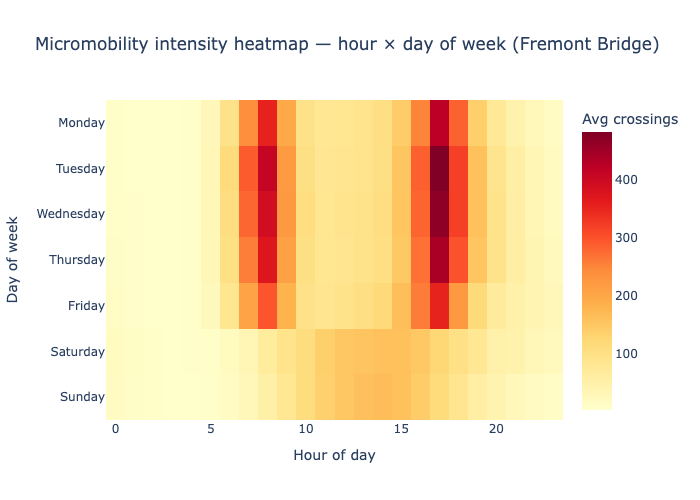

In [9]:
# Heatmap: average crossings by hour × weekday
heat = (
    df.groupby(["weekday", "hour"], as_index=False)[COL_TOTAL]
    .mean()
)
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heat["weekday"] = pd.Categorical(heat["weekday"], categories=day_order, ordered=True)
heat = heat.sort_values(["weekday", "hour"])
heat_pivot = heat.pivot(index="weekday", columns="hour", values=COL_TOTAL)

fig_heat = px.imshow(
    heat_pivot,
    labels=dict(x="Hour of day", y="Day of week", color="Avg crossings"),
    title="Micromobility intensity heatmap — hour × day of week (Fremont Bridge)",
    aspect="auto",
    color_continuous_scale="YlOrRd",
)
fig_heat.write_image(FIG_DIR / "heatmap_hour_weekday.png")
display(Image(filename=str(FIG_DIR / "heatmap_hour_weekday.png")))

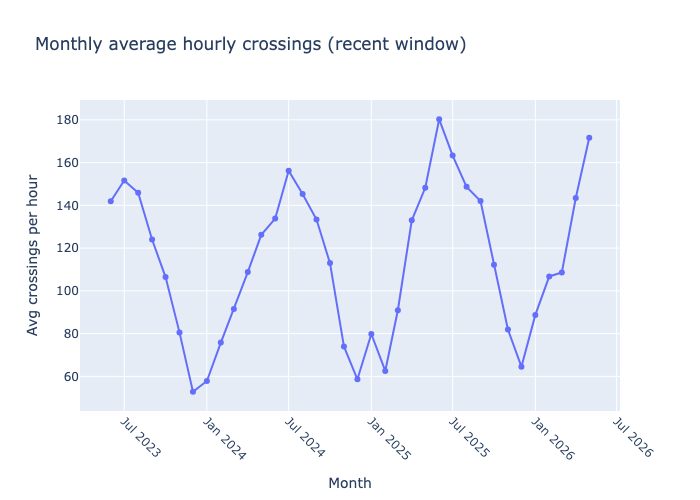

In [10]:
# Line: monthly trend (last 36 months for readability)
plot_monthly = monthly_df.tail(36)
fig_month = px.line(
    plot_monthly,
    x="year_month",
    y="avg_hourly_crossings",
    markers=True,
    title="Monthly average hourly crossings (recent window)",
    labels={"year_month": "Month", "avg_hourly_crossings": "Avg crossings per hour"},
)
fig_month.update_xaxes(tickangle=45)
fig_month.write_image(FIG_DIR / "monthly_trend.png")
display(Image(filename=str(FIG_DIR / "monthly_trend.png")))

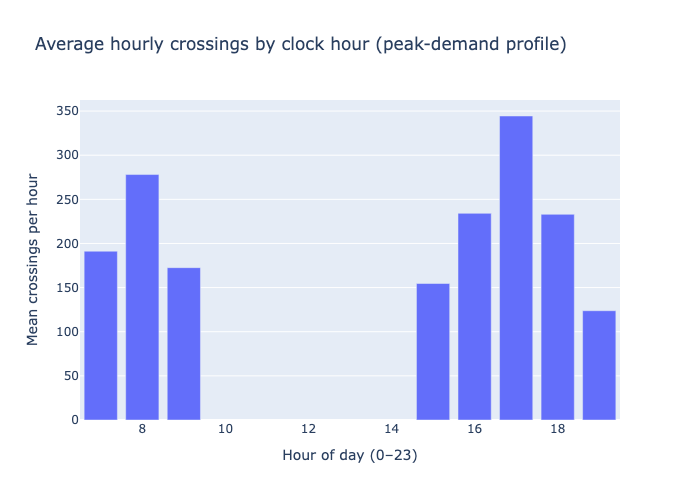

In [11]:
# Bar: top peak hours
fig_peak = px.bar(
    peak_hours_df.sort_values("hour"),
    x="hour",
    y="avg_crossings",
    title="Average hourly crossings by clock hour (peak-demand profile)",
    labels={"hour": "Hour of day (0–23)", "avg_crossings": "Mean crossings per hour"},
)
fig_peak.write_image(FIG_DIR / "peak_hours.png")
display(Image(filename=str(FIG_DIR / "peak_hours.png")))

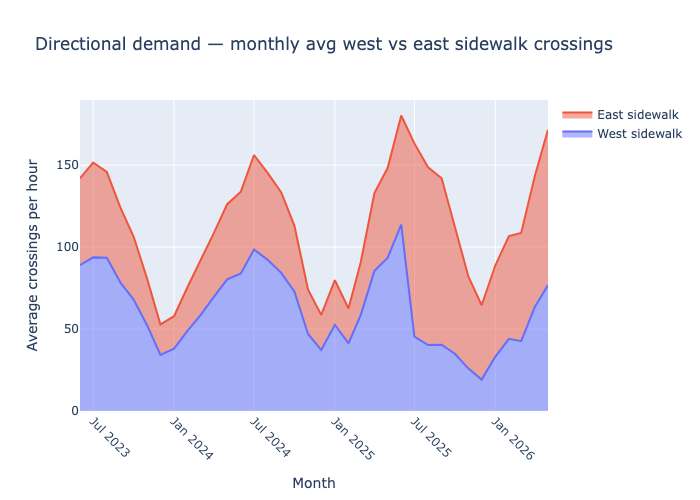

In [12]:
# Stacked area proxy: west vs east monthly means
monthly_dir = (
    df.groupby("year_month", as_index=False)
    .agg(avg_west=("crossings_west", "mean"), avg_east=("crossings_east", "mean"))
    .tail(36)
)
fig_dir = go.Figure()
fig_dir.add_trace(go.Scatter(x=monthly_dir["year_month"], y=monthly_dir["avg_west"], name="West sidewalk", stackgroup="one"))
fig_dir.add_trace(go.Scatter(x=monthly_dir["year_month"], y=monthly_dir["avg_east"], name="East sidewalk", stackgroup="one"))
fig_dir.update_layout(
    title="Directional demand — monthly avg west vs east sidewalk crossings",
    xaxis_title="Month",
    yaxis_title="Average crossings per hour",
)
fig_dir.update_xaxes(tickangle=45)
fig_dir.write_image(FIG_DIR / "directional_monthly.png")
display(Image(filename=str(FIG_DIR / "directional_monthly.png")))

---
## 4 · Auto-generated insight report

Copy this markdown into research readouts, workshop decks, or ops briefings.

In [13]:
report_md = build_insight_report(df)
report_path = MP2_DIR / "outputs" / "mobility_insight_report.md"
report_path.parent.mkdir(parents=True, exist_ok=True)
report_path.write_text(report_md, encoding="utf-8")
print(report_md)
print("\nSaved:", report_path)

# Mobility Insight Report — Fremont Bridge corridor

**Records analyzed:** 119,717 hourly observations (2012-10-02 → 2026-05-31).

## Peak demand
Typical **peak hours** (highest average crossings): **17:00, 08:00, 16:00**. Service teams can align field research, intercept surveys, or ops staffing with these windows when live rider behavior is most visible on this corridor.

## Weekday vs weekend
Weekday average hourly crossings: **122.5**; weekend: **69.7**. Weekdays run hotter — commute-linked micromobility use likely dominates.

## Directional balance
West sidewalk accounts for **54.9%** of crossings on average; west-dominant hours occur **63.2%** of the time. Asymmetric flow can inform placement of parking zones, charging hubs, or signage on one approach.

## Quiet windows (bottom decile by hour-of-day average)
Low-activity clock hours: 03:00, 02:00, 01:00. Useful for maintenance scheduling or studying barrier effects without peak-traffic noise.

## Research note
This feed is **hour

---
## 5 · How to run locally (CLI alternative)

```bash
cd MP2
python -c "from mobility_insights import load_and_clean, build_insight_report; from pathlib import Path; df=load_and_clean('data/fremont_micromobility_hourly.csv'); print(build_insight_report(df))"
```

**Audience reminder:** Built for researchers who need **quantitative scaffolding** before qualitative work — not a replacement for intercept interviews or ride-alongs.